# PPC6: Condução bidimensional em uma aleta retangular por diferenças finitas


link do repositório:  https://github.com/Felipe-Loureiro/calculo-numerico-aplicado-unb


Este notebook resolve numericamente o campo de temperatura em uma aleta retangular de seção transversal constante, em regime permanente, sem geração interna de calor e com propriedades térmicas constantes.

A base da aleta é mantida em uma temperatura prescrita $T_b$. As superfícies superior, inferior e a extremidade livre trocam calor por convecção com um ambiente a temperatura $T_\infty$.

# Aluno: Felipe Tavares Loureiro  
# Professor: Rafael Gabler Gontijo  
# Disciplina: ENM0227 - Cálculo Numérico Aplicado  
# Semestre: 2026.1

O programa atende às etapas principais propostas no PPC6:

- geração automática de uma malha bidimensional uniforme;
- montagem do sistema linear obtido por diferenças finitas;
- solução por eliminação de Gauss, Liebmann e Liebmann com relaxação;
- comparação entre os métodos;
- estudo do fator de relaxação e do refinamento de malha;
- comparação da linha central com a solução analítica unidimensional;
- geração de gráficos e exportação dos resultados numéricos para arquivos `.dat`.

Foram utilizados somente os módulos `math`, `os` e `matplotlib`.

# 1. Modelo físico, hipóteses e parâmetros de entrada

A equação governante para condução bidimensional em regime permanente, sem geração interna, é a equação de Laplace:

$$
\frac{\partial^2 T}{\partial x^2}+
\frac{\partial^2 T}{\partial y^2}=0.
$$

As hipóteses adotadas são:

- regime permanente;
- condutividade térmica constante;
- ausência de geração volumétrica de calor;
- profundidade unitária da aleta para a comparação com o modelo unidimensional;
- convecção uniforme nas superfícies expostas;
- malha cartesiana uniforme em $x$ e $y$.

A variável `usar_entrada_interativa` permite escolher entre duas formas de execução. Quando ela vale `False`, o notebook usa um conjunto de parâmetros padrão, o que facilita a reprodução dos resultados. Quando vale `True`, os valores são solicitados ao usuário.

Os dados serão gravados na pasta `resultados_PPC6`, criada automaticamente no diretório de execução do notebook.

In [1]:
import math                              # Funções hiperbólicas, raiz quadrada e teste de valores finitos
import os                                # Criação de pastas, escrita de arquivos e medição de tempo
import matplotlib.pyplot as plt          # Construção dos gráficos solicitados no PPC


# Configurações gerais dos gráficos. Essas opções afetam todas as figuras do notebook.
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


def ler_valor(mensagem, padrao, inteiro=False, minimo=None, maximo=None):
    """Lê um valor numérico, permitindo que Enter mantenha o valor padrão."""

    while True:
        texto = input("{} [{}]: ".format(mensagem, padrao)).strip()

        try:
            # A conversão é feita para inteiro apenas nos parâmetros de número de nós.
            if texto:
                valor = int(texto) if inteiro else float(texto)
            else:
                valor = padrao

            # Os limites evitam parâmetros fisicamente ou numericamente inválidos.
            if minimo is not None and valor < minimo:
                print("O valor deve ser maior ou igual a {}.".format(minimo))
                continue

            if maximo is not None and valor > maximo:
                print("O valor deve ser menor ou igual a {}.".format(maximo))
                continue

            return valor

        except ValueError:
            print("Entrada inválida. Digite um valor numérico.")


# Altere para True caso queira fornecer todos os dados durante a execução.
usar_entrada_interativa = False


if usar_entrada_interativa:
    L = ler_valor("Comprimento da aleta L [m]", 0.10, minimo=1e-12)
    H = ler_valor("Espessura da aleta H [m]", 0.01, minimo=1e-12)
    k = ler_valor("Condutividade térmica k [W/(m.K)]", 200.0, minimo=1e-12)
    h = ler_valor("Coeficiente convectivo h [W/(m².K)]", 25.0, minimo=1e-12)
    Tb = ler_valor("Temperatura prescrita na base Tb", 100.0)
    Tinf = ler_valor("Temperatura ambiente Tinf", 25.0)
    nx = ler_valor("Número de nós na direção x", 21, inteiro=True, minimo=3)
    ny = ler_valor("Número de nós na direção y", 9, inteiro=True, minimo=3)
    tol = ler_valor("Tolerância absoluta de convergência [K]", 1e-8, minimo=1e-15)
    omega = ler_valor("Fator de relaxação omega", 1.5, minimo=1e-6, maximo=1.999999)

else:
    # Parâmetros geométricos.
    L = 0.10                              # Comprimento da aleta [m]
    H = 0.01                              # Espessura da aleta [m]

    # Propriedades térmicas e condições de contorno.
    k = 200.0                             # Condutividade térmica [W/(m.K)]
    h = 25.0                              # Coeficiente convectivo [W/(m².K)]
    Tb = 100.0                            # Temperatura prescrita na base
    Tinf = 25.0                           # Temperatura do fluido ambiente

    # Parâmetros numéricos.
    nx = 21                               # Número de nós na direção x
    ny = 9                                # Número de nós na direção y
    tol = 1e-8                            # Tolerância para a maior mudança nodal entre iterações [K]
    omega = 1.5                           # Fator de relaxação do caso principal


# A matriz densa usada na eliminação de Gauss cresce com o quadrado do número de nós.
# O aviso não impede a execução, mas lembra que malhas muito grandes tornam o método direto caro.
if nx * ny > 400:
    print("Aviso: a eliminação de Gauss densa pode ficar lenta para mais de 400 nós.")


# A pasta é criada apenas se ainda não existir.
pasta = os.path.join(os.getcwd(), "resultados_PPC6")

if not os.path.isdir(pasta):
    os.makedirs(pasta)


print("Parâmetros principais:")
print("L = {:.5f} m | H = {:.5f} m".format(L, H))
print("k = {:.3f} W/(m.K) | h = {:.3f} W/(m².K)".format(k, h))
print("Tb = {:.3f} | Tinf = {:.3f}".format(Tb, Tinf))
print("Malha = {} x {} = {} nós".format(nx, ny, nx * ny))
print("Tolerância = {:.3e} | omega principal = {:.3f}".format(tol, omega))
print("Pasta de resultados:", pasta)

Parâmetros principais:
L = 0.10000 m | H = 0.01000 m
k = 200.000 W/(m.K) | h = 25.000 W/(m².K)
Tb = 100.000 | Tinf = 25.000
Malha = 21 x 9 = 189 nós
Tolerância = 1.000e-08 | omega principal = 1.500
Pasta de resultados: /tmp/ppc6_exec/resultados_PPC6


# 2. Discretização espacial e numeração global

Para uma malha uniforme, os espaçamentos são

$$
\Delta x=\frac{L}{n_x-1},
\qquad
\Delta y=\frac{H}{n_y-1}.
$$

Cada nó é identificado pelos índices bidimensionais $(i,j)$ e por um único índice global

$$
p=j\,n_x+i.
$$

Essa numeração faz com que $x$ varie primeiro. Em seguida, passa-se para a próxima fileira em $y$.

## Nó interno

A aproximação por diferenças finitas centradas fornece

$$
\frac{T_{i+1,j}-2T_{i,j}+T_{i-1,j}}{\Delta x^2}
+
\frac{T_{i,j+1}-2T_{i,j}+T_{i,j-1}}{\Delta y^2}=0.
$$

Organizando a equação com diagonal positiva:

$$
\left(\frac{2}{\Delta x^2}+\frac{2}{\Delta y^2}\right)T_{i,j}
-
\frac{T_{i-1,j}+T_{i+1,j}}{\Delta x^2}
-
\frac{T_{i,j-1}+T_{i,j+1}}{\Delta y^2}=0.
$$

## Base aquecida

Na base, correspondente a $x=0$, a condição de Dirichlet é aplicada diretamente:

$$
T_{0,j}=T_b.
$$

## Superfícies convectivas

Nas demais superfícies é aplicada a condição de Robin

$$
-k\frac{\partial T}{\partial n}=h(T-T_\infty).
$$

A derivada normal é aproximada por diferenças centradas usando um nó fictício. O nó fictício é então eliminado com a própria condição convectiva. Dessa forma, as equações das fronteiras permanecem escritas apenas em função dos nós físicos da malha.

Nos cantos convectivos, duas condições de Robin atuam simultaneamente: uma na direção $x$ e outra na direção $y$. A contribuição de cada superfície é acrescentada à diagonal e ao vetor independente.

In [2]:
def montar_sistema(L, H, k, h, Tb, Tinf, nx, ny):
    """Monta a forma esparsa do sistema linear A*T = b para a aleta 2D."""

    # Número total de incógnitas e espaçamentos da malha.
    n = nx * ny
    dx = L / (nx - 1)
    dy = H / (ny - 1)

    # beta = h/k aparece repetidamente na eliminação dos nós fictícios.
    beta = h / k

    # Coeficientes das derivadas segundas em x e y.
    ax = 1.0 / (dx * dx)
    ay = 1.0 / (dy * dy)

    # Cada posição de "linhas" armazena apenas os coeficientes não nulos da linha correspondente.
    # Um elemento (coluna, valor) representa A[linha][coluna] = valor.
    linhas = [[] for p in range(n)]
    b = [0.0] * n

    # Coordenadas físicas associadas aos nós.
    x = [i * dx for i in range(nx)]
    y = [j * dy for j in range(ny)]

    for j in range(ny):
        for i in range(nx):
            # Numeração global: todos os nós de uma fileira em x vêm antes da fileira seguinte.
            p = j * nx + i

            # A base inteira, inclusive seus dois cantos, possui temperatura prescrita.
            # A linha do sistema contém apenas 1*T_p = Tb.
            if i == 0:
                linhas[p] = [(p, 1.0)]
                b[p] = Tb
                continue

            # A parte interna do Laplaciano contribui inicialmente com 2*ax + 2*ay na diagonal.
            diagonal = 2.0 * ax + 2.0 * ay
            coeficientes = []

            # Tratamento da direção x.
            if i == nx - 1:
                # Na extremidade livre, a convecção elimina o nó fictício a leste.
                # O vizinho oeste aparece com peso dobrado.
                coeficientes.append((p - 1, -2.0 * ax))

                # A condição de Robin acrescenta um termo à diagonal e outro ao vetor b.
                diagonal += 2.0 * beta / dx
                b[p] += 2.0 * beta * Tinf / dx

            else:
                # Para nós que não pertencem à ponta, existem vizinhos oeste e leste.
                coeficientes.append((p - 1, -ax))
                coeficientes.append((p + 1, -ax))

            # Tratamento da direção y.
            if j == 0:
                # Superfície inferior: o nó fictício abaixo da malha é eliminado.
                # O vizinho superior aparece com peso dobrado.
                coeficientes.append((p + nx, -2.0 * ay))
                diagonal += 2.0 * beta / dy
                b[p] += 2.0 * beta * Tinf / dy

            elif j == ny - 1:
                # Superfície superior: o nó fictício acima da malha é eliminado.
                # O vizinho inferior aparece com peso dobrado.
                coeficientes.append((p - nx, -2.0 * ay))
                diagonal += 2.0 * beta / dy
                b[p] += 2.0 * beta * Tinf / dy

            else:
                # Um nó que não pertence às superfícies horizontais possui vizinhos sul e norte.
                coeficientes.append((p - nx, -ay))
                coeficientes.append((p + nx, -ay))

            # O termo diagonal é armazenado primeiro apenas para facilitar a leitura posterior.
            linhas[p] = [(p, diagonal)] + coeficientes

    return b, linhas, x, y, dx, dy


def eliminacao_gauss(A, b):
    """Resolve um sistema linear denso por Gauss com pivoteamento parcial."""

    n = len(b)

    # As cópias preservam A e b para que o mesmo sistema seja usado nos outros métodos.
    M = [linha[:] for linha in A]
    d = b[:]

    # Etapa de eliminação: transforma M em uma matriz triangular superior.
    for k_gauss in range(n - 1):
        linha_pivo = k_gauss

        # O pivoteamento parcial procura o maior elemento, em módulo, na coluna atual.
        for i in range(k_gauss + 1, n):
            if abs(M[i][k_gauss]) > abs(M[linha_pivo][k_gauss]):
                linha_pivo = i

        # Um pivô praticamente nulo indica singularidade ou forte mau condicionamento.
        if abs(M[linha_pivo][k_gauss]) < 1e-30:
            raise ValueError("Matriz singular ou quase singular.")

        # A linha de maior pivô é colocada na posição corrente.
        if linha_pivo != k_gauss:
            M[k_gauss], M[linha_pivo] = M[linha_pivo], M[k_gauss]
            d[k_gauss], d[linha_pivo] = d[linha_pivo], d[k_gauss]

        # Elimina os elementos abaixo do pivô.
        for i in range(k_gauss + 1, n):
            if M[i][k_gauss] == 0.0:
                continue

            fator = M[i][k_gauss] / M[k_gauss][k_gauss]
            M[i][k_gauss] = 0.0

            for j in range(k_gauss + 1, n):
                M[i][j] -= fator * M[k_gauss][j]

            d[i] -= fator * d[k_gauss]

    # Substituição regressiva para recuperar o vetor de temperaturas.
    T = [0.0] * n

    for i in range(n - 1, -1, -1):
        soma = d[i]

        for j in range(i + 1, n):
            soma -= M[i][j] * T[j]

        if abs(M[i][i]) < 1e-30:
            raise ValueError("Pivô nulo na substituição regressiva.")

        T[i] = soma / M[i][i]

    return T


def liebmann(linhas, b, chute, tol, omega=1.0, max_iter=200000):
    """Resolve o sistema esparso por Liebmann; omega=1 fornece Gauss-Seidel."""

    T = chute[:]
    erro = tol * 10.0
    iteracao = 0
    historico = []

    while erro > tol and iteracao < max_iter:
        erro = 0.0

        for i in range(len(T)):
            antigo = T[i]
            soma = b[i]
            diagonal = 0.0

            # Como os valores de T são atualizados imediatamente, o método é Gauss-Seidel.
            for j, coeficiente in linhas[i]:
                if j == i:
                    diagonal = coeficiente
                else:
                    soma -= coeficiente * T[j]

            # Valor obtido pelo passo puro de Gauss-Seidel.
            valor_gauss_seidel = soma / diagonal

            # A combinação abaixo aplica sub-relaxação, Gauss-Seidel puro ou sobre-relaxação.
            T[i] = (
                (1.0 - omega) * antigo
                + omega * valor_gauss_seidel
            )

            # O critério de parada usa a maior mudança absoluta entre duas iterações sucessivas.
            mudanca = abs(T[i] - antigo)

            if mudanca > erro:
                erro = mudanca

        iteracao += 1
        historico.append(erro)

        # Esta verificação interrompe casos divergentes antes de gerar overflow indefinidamente.
        if not math.isfinite(erro) or erro > 1e100:
            break

    convergiu = erro <= tol

    return T, iteracao, erro, convergiu, historico


def residuo_maximo(linhas, b, T):
    """Calcula o maior resíduo relativo escalado das equações do sistema."""

    maior = 0.0

    for i in range(len(T)):
        valor = -b[i]
        escala = abs(b[i])

        for j, coeficiente in linhas[i]:
            termo = coeficiente * T[j]
            valor += termo
            escala += abs(termo)

        # O escalonamento evita comparar resíduos de equações com ordens de grandeza diferentes.
        if escala > 1e-30:
            residuo = abs(valor) / escala
        else:
            residuo = abs(valor)

        if residuo > maior:
            maior = residuo

    return maior

# 3. Montagem do sistema e solução pelos três métodos

A estrutura `linhas` armazena somente os coeficientes não nulos de cada equação. Isso é adequado ao problema porque um nó interno se acopla apenas a si próprio e aos quatro vizinhos mais próximos. Portanto, mesmo quando o número total de nós cresce, o número de coeficientes não nulos por linha permanece pequeno.

Para a eliminação de Gauss, a representação esparsa é convertida para uma matriz densa. Essa conversão é feita apenas porque o objetivo do PPC é comparar explicitamente um método direto com os métodos iterativos. Para malhas grandes, a matriz densa desperdiça memória e o custo computacional da eliminação cresce rapidamente.

Nos métodos iterativos, o chute inicial é $T_\infty$ em todo o domínio, exceto na base, que já começa em $T_b$. São comparados:

- **Eliminação de Gauss:** solução direta usada como referência;
- **Liebmann sem relaxação:** equivalente a Gauss-Seidel, com $\omega=1$;
- **Liebmann com relaxação:** usa o valor de $\omega$ definido nos parâmetros.

Além da maior mudança nodal entre iterações, é calculado o resíduo do sistema $A\,T-b$. A concordância com a solução de Gauss é medida pela maior diferença absoluta entre os vetores de temperatura.


Características da malha e da matriz:
dx = 5.000000e-03 m | dy = 1.250000e-03 m
Coeficientes não nulos = 860
Densidade da matriz = 2.4075%

Comparação dos métodos:
Gauss      | resíduo = 1.285e-10 | tempo = 0.020000 s
Liebmann   | iterações =  37345 | erro = 9.997e-09 | resíduo = 5.330e-11 | tempo = 1.950000 s | convergiu = True
Relaxado   | iterações =  13343 | erro = 9.993e-09 | resíduo = 3.497e-11 | tempo = 0.710000 s | convergiu = True
Diferença máxima Liebmann/Gauss = 2.479305e-05 K
Diferença máxima relaxado/Gauss = 8.250264e-06 K


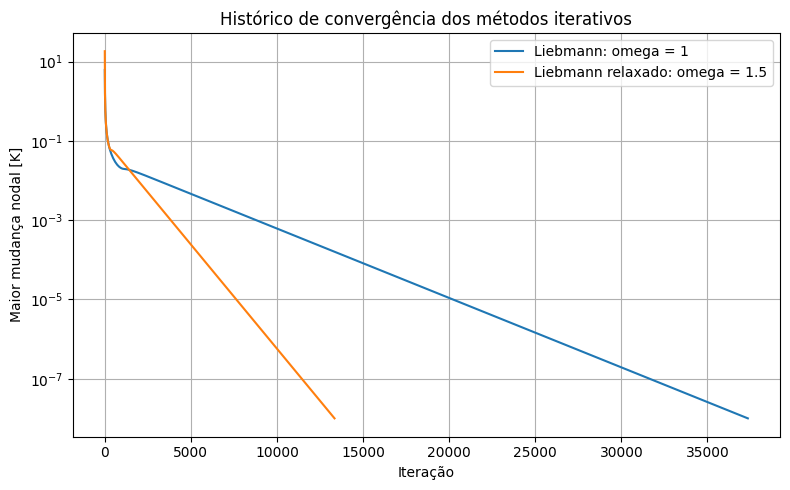

In [3]:
# Montagem da forma esparsa do sistema.
b, linhas, x, y, dx, dy = montar_sistema(
    L,
    H,
    k,
    h,
    Tb,
    Tinf,
    nx,
    ny,
)

n = nx * ny


# A matriz densa é criada apenas para a eliminação de Gauss.
# Os métodos de Liebmann continuam usando a estrutura esparsa em "linhas".
A = [[0.0 for coluna in range(n)] for linha in range(n)]

for i in range(n):
    for j, coeficiente in linhas[i]:
        A[i][j] = coeficiente


# Número de coeficientes não nulos e densidade percentual da matriz.
nnz = sum(len(linha) for linha in linhas)
densidade = 100.0 * nnz / (n * n)


# Chute inicial dos métodos iterativos.
chute = [Tinf] * n

for j in range(ny):
    chute[j * nx] = Tb                  # Impõe a base aquecida desde a condição inicial


# Solução direta por eliminação de Gauss.
inicio = os.times()[4]
T_gauss = eliminacao_gauss(A, b)
tempo_gauss = os.times()[4] - inicio


# Solução por Liebmann sem relaxação, isto é, Gauss-Seidel puro.
inicio = os.times()[4]
T_lieb, it_lieb, erro_lieb, ok_lieb, hist_lieb = liebmann(
    linhas,
    b,
    chute,
    tol,
    omega=1.0,
)
tempo_lieb = os.times()[4] - inicio


# Solução por Liebmann com o fator de relaxação escolhido.
inicio = os.times()[4]
T_relax, it_relax, erro_relax, ok_relax, hist_relax = liebmann(
    linhas,
    b,
    chute,
    tol,
    omega=omega,
)
tempo_relax = os.times()[4] - inicio


# Resíduos escalados de cada solução.
res_gauss = residuo_maximo(linhas, b, T_gauss)
res_lieb = residuo_maximo(linhas, b, T_lieb)
res_relax = residuo_maximo(linhas, b, T_relax)


# Diferenças máximas dos métodos iterativos em relação à solução direta.
dif_lieb = max(
    abs(T_lieb[i] - T_gauss[i])
    for i in range(n)
)

dif_relax = max(
    abs(T_relax[i] - T_gauss[i])
    for i in range(n)
)


print("\nCaracterísticas da malha e da matriz:")
print("dx = {:.6e} m | dy = {:.6e} m".format(dx, dy))
print("Coeficientes não nulos = {}".format(nnz))
print("Densidade da matriz = {:.4f}%".format(densidade))

print("\nComparação dos métodos:")
print(
    "Gauss      | resíduo = {:.3e} | tempo = {:.6f} s".format(
        res_gauss,
        tempo_gauss,
    )
)
print(
    "Liebmann   | iterações = {:6d} | erro = {:.3e} | resíduo = {:.3e} | tempo = {:.6f} s | convergiu = {}".format(
        it_lieb,
        erro_lieb,
        res_lieb,
        tempo_lieb,
        ok_lieb,
    )
)
print(
    "Relaxado   | iterações = {:6d} | erro = {:.3e} | resíduo = {:.3e} | tempo = {:.6f} s | convergiu = {}".format(
        it_relax,
        erro_relax,
        res_relax,
        tempo_relax,
        ok_relax,
    )
)
print("Diferença máxima Liebmann/Gauss = {:.6e} K".format(dif_lieb))
print("Diferença máxima relaxado/Gauss = {:.6e} K".format(dif_relax))


# O histórico permite visualizar a redução do erro iterativo ao longo das iterações.
plt.figure()
plt.semilogy(
    range(1, len(hist_lieb) + 1),
    hist_lieb,
    label="Liebmann: omega = 1",
)
plt.semilogy(
    range(1, len(hist_relax) + 1),
    hist_relax,
    label="Liebmann relaxado: omega = {}".format(omega),
)
plt.xlabel("Iteração")
plt.ylabel("Maior mudança nodal [K]")
plt.title("Histórico de convergência dos métodos iterativos")
plt.legend()
plt.tight_layout()
plt.show()

## Análise da comparação entre os métodos

A eliminação de Gauss e os dois métodos de Liebmann resolvem exatamente o mesmo sistema discretizado. Portanto, quando os métodos iterativos convergem até uma tolerância suficientemente pequena, suas temperaturas devem se aproximar da solução direta.

A diferença entre os métodos está principalmente no custo computacional e na forma de armazenamento:

- a eliminação de Gauss trabalha com a matriz densa e realiza operações também sobre muitos elementos nulos;
- o método de Liebmann usa somente os coeficientes realmente presentes em cada linha;
- a sobre-relaxação pode reduzir significativamente o número de iterações, mas valores excessivos de $\omega$ podem tornar a convergência lenta, oscilatória ou até divergente.

O resíduo verifica se a solução satisfaz as equações algébricas, enquanto a mudança nodal verifica se o processo iterativo deixou de alterar significativamente o campo. Usar as duas medidas é mais informativo do que confiar apenas em um único critério.

Os resultados numéricos específicos do conjunto padrão aparecem na saída da célula anterior. Uma diferença muito pequena em relação a Gauss confirma a implementação dos métodos iterativos; um resíduo pequeno confirma que o vetor final satisfaz o sistema montado.

### Resultado com os parâmetros padrão

A malha principal possui 189 nós e a matriz contém 860 coeficientes não nulos, correspondendo a apenas **2,4075%** dos elementos da matriz densa. Isso confirma quantitativamente a forte esparsidade do sistema.

O Liebmann sem relaxação convergiu em **37.345 iterações**. Com $\omega=1{,}5$, o número caiu para **13.343 iterações**, uma redução de aproximadamente **64%**. As diferenças máximas em relação a Gauss foram de $2{,}48\times10^{-5}$ K e $8{,}25\times10^{-6}$ K, respectivamente, valores desprezíveis diante da faixa de temperatura do problema.

Para esta malha pequena, a eliminação de Gauss densa foi mais rápida. Isso não significa que ela seja a melhor escolha para refinamentos sucessivos: seu custo cresce muito mais rapidamente e ela armazena todos os zeros, enquanto Liebmann trabalha diretamente com a estrutura esparsa.

# 4. Exportação do sistema e dos campos de temperatura

Os arquivos de campo possuem três colunas: $x$, $y$ e $T$. Uma linha em branco separa as fileiras da malha, o que facilita a leitura e também permite que programas de visualização reconheçam a estrutura bidimensional.

A matriz é exportada em formato esparso, com as colunas `linha`, `coluna` e `Aij`. Isso evita escrever todos os zeros da matriz densa.

Também são gravados:

- um arquivo com a comparação global entre os métodos;
- um arquivo com o histórico de convergência dos dois casos iterativos principais.

In [4]:
# Exporta os três campos completos de temperatura.
campos = [
    ("campo_gauss.dat", T_gauss),
    ("campo_liebmann.dat", T_lieb),
    ("campo_relaxado.dat", T_relax),
]

for nome, temperaturas in campos:
    caminho = os.path.join(pasta, nome)

    with open(caminho, "w") as arquivo:
        arquivo.write("# x[m] y[m] T\n")

        for j in range(ny):
            for i in range(nx):
                p = j * nx + i

                arquivo.write(
                    "{:.12e} {:.12e} {:.12e}\n".format(
                        x[i],
                        y[j],
                        temperaturas[p],
                    )
                )

            # A linha vazia separa visualmente as fileiras da malha.
            arquivo.write("\n")


# Exporta somente os elementos não nulos da matriz e, ao final, o vetor independente.
caminho_sistema = os.path.join(pasta, "sistema_linear_esparso.dat")

with open(caminho_sistema, "w") as arquivo:
    arquivo.write("# linha coluna Aij\n")

    for i in range(n):
        for j, coeficiente in linhas[i]:
            arquivo.write(
                "{} {} {:.12e}\n".format(
                    i,
                    j,
                    coeficiente,
                )
            )

    arquivo.write("\n# linha bi\n")

    for i in range(n):
        arquivo.write("{} {:.12e}\n".format(i, b[i]))


# Tabela resumida com as principais métricas de cada método.
caminho_comparacao = os.path.join(pasta, "comparacao_metodos.dat")

with open(caminho_comparacao, "w") as arquivo:
    arquivo.write(
        "# metodo iteracoes erro_final residuo tempo[s] convergiu diferenca_maxima_para_gauss[K]\n"
    )
    arquivo.write(
        "Gauss 0 0.0 {:.12e} {:.12e} 1 0.0\n".format(
            res_gauss,
            tempo_gauss,
        )
    )
    arquivo.write(
        "Liebmann {} {:.12e} {:.12e} {:.12e} {} {:.12e}\n".format(
            it_lieb,
            erro_lieb,
            res_lieb,
            tempo_lieb,
            int(ok_lieb),
            dif_lieb,
        )
    )
    arquivo.write(
        "Relaxado {} {:.12e} {:.12e} {:.12e} {} {:.12e}\n".format(
            it_relax,
            erro_relax,
            res_relax,
            tempo_relax,
            int(ok_relax),
            dif_relax,
        )
    )


# Histórico de convergência. Quando um método termina antes, a coluna correspondente fica vazia.
caminho_historico = os.path.join(pasta, "historico_convergencia.dat")
maior_historico = max(len(hist_lieb), len(hist_relax))

with open(caminho_historico, "w") as arquivo:
    arquivo.write("# iteracao erro_liebmann erro_relaxado\n")

    for indice in range(maior_historico):
        erro_1 = ""
        erro_2 = ""

        if indice < len(hist_lieb):
            erro_1 = "{:.12e}".format(hist_lieb[indice])

        if indice < len(hist_relax):
            erro_2 = "{:.12e}".format(hist_relax[indice])

        arquivo.write(
            "{} {} {}\n".format(
                indice + 1,
                erro_1,
                erro_2,
            )
        )


print("Arquivos dos métodos e do sistema linear salvos em:", pasta)

Arquivos dos métodos e do sistema linear salvos em: /tmp/ppc6_exec/resultados_PPC6


# 5. Linha central e solução analítica unidimensional

A solução analítica clássica considera que a temperatura é uniforme em cada seção transversal. Definindo

$$
\theta(x)=\frac{T(x)-T_\infty}{T_b-T_\infty},
$$

e

$$
m=\sqrt{\frac{hP}{kA_c}},
$$

para uma aleta com extremidade convectiva obtém-se

$$
\theta(x)=
\frac{
\cosh[m(L-x)]+\dfrac{h}{mk}\sinh[m(L-x)]
}{
\cosh(mL)+\dfrac{h}{mk}\sinh(mL)
}.
$$

Como a profundidade é tomada como unitária, são usados

$$
A_c=H,
\qquad
P=2.
$$

Esse perímetro representa as superfícies superior e inferior por unidade de profundidade. A comparação não é uma validação exata do modelo bidimensional, porque o modelo 1D ignora gradientes em $y$ e os efeitos locais dos cantos. Ela serve para avaliar a proximidade entre as duas idealizações.

Quando `ny` é ímpar, existe uma fileira exatamente na linha central. Quando `ny` é par, a temperatura central é aproximada pela média das duas fileiras mais próximas do eixo geométrico.

Parâmetro analítico m = 5.000000e+00 1/m
Erro percentual médio entre a linha central 2D e a solução 1D = 0.008885%
Erro percentual máximo entre as duas soluções = 0.009995%


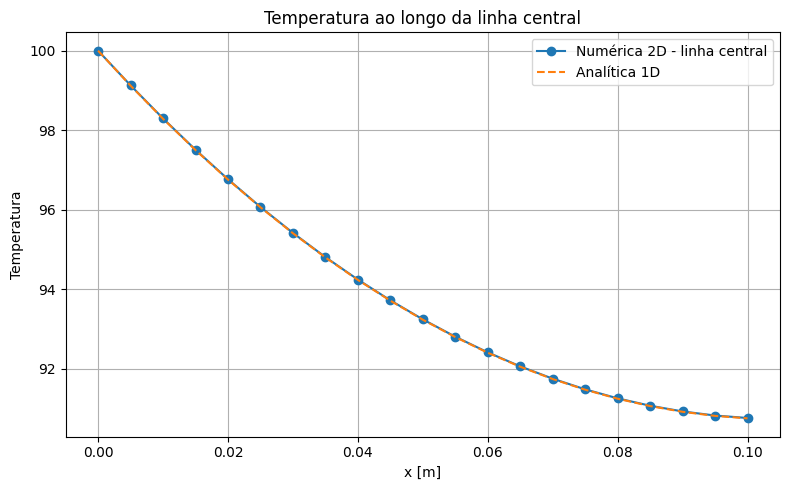

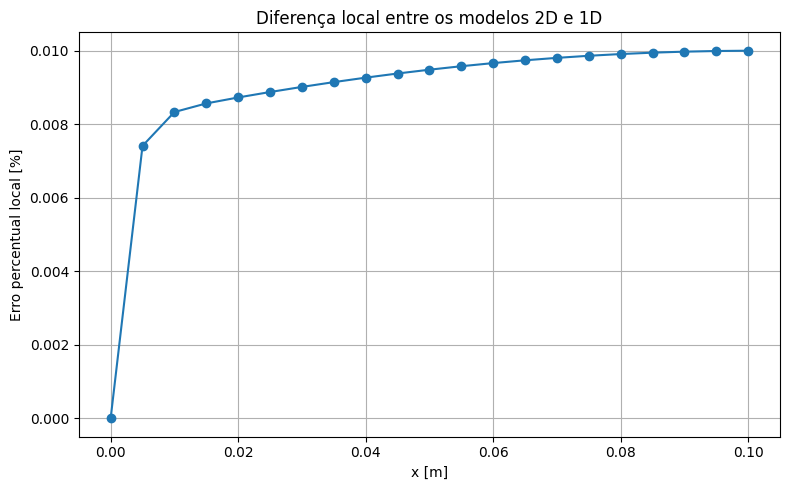

In [5]:
# Extração da temperatura numérica ao longo da linha central da aleta.
if ny % 2 == 1:
    j_centro = ny // 2
    T_centro = [
        T_relax[j_centro * nx + i]
        for i in range(nx)
    ]

else:
    j_inferior = ny // 2 - 1
    j_superior = ny // 2

    T_centro = [
        0.5 * (
            T_relax[j_inferior * nx + i]
            + T_relax[j_superior * nx + i]
        )
        for i in range(nx)
    ]


# Parâmetros geométricos por unidade de profundidade.
area_secao = H
perimetro_convectivo = 2.0

# Parâmetro m da solução analítica e termo associado à ponta convectiva.
m = math.sqrt(
    h * perimetro_convectivo
    / (k * area_secao)
)

fator_ponta = h / (m * k)

denominador = (
    math.cosh(m * L)
    + fator_ponta * math.sinh(m * L)
)


T_analitica = []
erros_ponto = []

for i in range(nx):
    numerador = (
        math.cosh(m * (L - x[i]))
        + fator_ponta * math.sinh(m * (L - x[i]))
    )

    theta = numerador / denominador
    valor_analitico = Tinf + (Tb - Tinf) * theta

    T_analitica.append(valor_analitico)

    # O erro é normalizado pela temperatura analítica em módulo.
    # A escala mínima evita divisão por zero em casos especiais.
    escala = max(
        abs(valor_analitico),
        abs(Tb - Tinf) * 1e-12,
        1e-12,
    )

    erro_local = 100.0 * abs(T_centro[i] - valor_analitico) / escala
    erros_ponto.append(erro_local)


erro_percentual = sum(erros_ponto) / len(erros_ponto)
erro_percentual_maximo = max(erros_ponto)


print("Parâmetro analítico m = {:.6e} 1/m".format(m))
print(
    "Erro percentual médio entre a linha central 2D e a solução 1D = {:.6f}%".format(
        erro_percentual
    )
)
print(
    "Erro percentual máximo entre as duas soluções = {:.6f}%".format(
        erro_percentual_maximo
    )
)


# Exportação da comparação ponto a ponto.
caminho_linha_central = os.path.join(pasta, "linha_central_comparacao.dat")

with open(caminho_linha_central, "w") as arquivo:
    arquivo.write("# x[m] T_2D T_analitica_1D erro_percentual\n")

    for i in range(nx):
        arquivo.write(
            "{:.12e} {:.12e} {:.12e} {:.12e}\n".format(
                x[i],
                T_centro[i],
                T_analitica[i],
                erros_ponto[i],
            )
        )


# Comparação visual entre o modelo bidimensional e a aproximação unidimensional.
plt.figure()
plt.plot(
    x,
    T_centro,
    "o-",
    label="Numérica 2D - linha central",
)
plt.plot(
    x,
    T_analitica,
    "--",
    label="Analítica 1D",
)
plt.xlabel("x [m]")
plt.ylabel("Temperatura")
plt.title("Temperatura ao longo da linha central")
plt.legend()
plt.tight_layout()
plt.show()


# O gráfico do erro local ajuda a identificar onde as hipóteses 1D e 2D mais diferem.
plt.figure()
plt.plot(x, erros_ponto, "o-")
plt.xlabel("x [m]")
plt.ylabel("Erro percentual local [%]")
plt.title("Diferença local entre os modelos 2D e 1D")
plt.tight_layout()
plt.show()

## Análise da comparação 2D × 1D

As duas soluções devem apresentar a mesma tendência física geral: a temperatura é máxima na base e diminui em direção à extremidade livre, pois a convecção remove calor continuamente ao longo da aleta.

A coincidência perfeita não é esperada. A solução analítica 1D pressupõe temperatura uniforme em cada seção transversal, enquanto o modelo 2D permite que os nós próximos às superfícies superior e inferior se resfriem mais do que os nós próximos à linha central. O modelo 2D também trata explicitamente os cantos e a condição convectiva da ponta.

Em geral, a aproximação 1D tende a melhorar quando o gradiente transversal é pequeno. Isso ocorre com maior facilidade em aletas finas, de alta condutividade e com convecção moderada. Se a espessura ou o coeficiente convectivo aumentarem, ou se a condutividade diminuir, os gradientes em $y$ se tornam mais importantes e a diferença entre as duas descrições pode crescer.

O erro local permite observar onde essa diferença se concentra. Próximo à base, a condição prescrita força ambas as soluções a começar em $T_b$. Longe da base, os efeitos acumulados da convecção lateral e o tratamento bidimensional da ponta passam a ter maior influência.

### Resultado com os parâmetros padrão

O erro percentual médio foi de **0,008885%**, e o maior erro local foi de aproximadamente **0,009995%**. A concordância é muito alta porque a aleta adotada é fina, possui alta condutividade e está submetida a um coeficiente convectivo moderado. Nessas condições, os gradientes transversais são pequenos e a hipótese unidimensional funciona muito bem.

Mesmo assim, o erro não é exatamente nulo. O pequeno desvio remanescente é coerente com os efeitos bidimensionais que a solução analítica não representa, principalmente o resfriamento transversal e o tratamento explícito dos cantos convectivos.

# 6. Estudo do fator de relaxação

O método de Liebmann relaxado usa

$$
T_i^{(novo)}=(1-\omega)T_i^{(antigo)}+\omega T_{i,GS},
$$

em que $T_{i,GS}$ é o valor produzido pelo passo de Gauss-Seidel.

- Para $0<\omega<1$, ocorre **sub-relaxação**. As atualizações são menores e a convergência costuma ser mais robusta, porém mais lenta.
- Para $\omega=1$, recupera-se o método de Gauss-Seidel sem relaxação.
- Para $1<\omega<2$, ocorre **sobre-relaxação**. Um valor adequado pode acelerar bastante a convergência.
- Um valor de $\omega$ muito próximo de 2 pode produzir oscilações fortes e prejudicar ou impedir a convergência.

O melhor valor depende da malha e dos coeficientes do sistema. Por isso, ele é estudado numericamente em vez de ser assumido como universal.

omega = 0.50 | iterações = 103880 | erro = 1.000e-08 | resíduo = 1.082e-10 | tempo = 5.6200 s | convergiu = True


omega = 0.80 | iterações =  54514 | erro = 9.999e-09 | resíduo = 6.705e-11 | tempo = 3.0100 s | convergiu = True


omega = 1.00 | iterações =  37345 | erro = 9.997e-09 | resíduo = 5.330e-11 | tempo = 1.9600 s | convergiu = True


omega = 1.20 | iterações =  25562 | erro = 9.997e-09 | resíduo = 4.415e-11 | tempo = 1.3500 s | convergiu = True


omega = 1.40 | iterações =  16895 | erro = 9.998e-09 | resíduo = 3.761e-11 | tempo = 0.8800 s | convergiu = True


omega = 1.50 | iterações =  13343 | erro = 9.993e-09 | resíduo = 3.497e-11 | tempo = 0.7800 s | convergiu = True


omega = 1.60 | iterações =  10177 | erro = 1.000e-08 | resíduo = 3.270e-11 | tempo = 0.5700 s | convergiu = True


omega = 1.70 | iterações =   7324 | erro = 9.985e-09 | resíduo = 3.063e-11 | tempo = 0.3900 s | convergiu = True


omega = 1.80 | iterações =   4715 | erro = 9.984e-09 | resíduo = 2.881e-11 | tempo = 0.2500 s | convergiu = True
omega = 1.90 | iterações =   2265 | erro = 9.976e-09 | resíduo = 2.709e-11 | tempo = 0.1200 s | convergiu = True


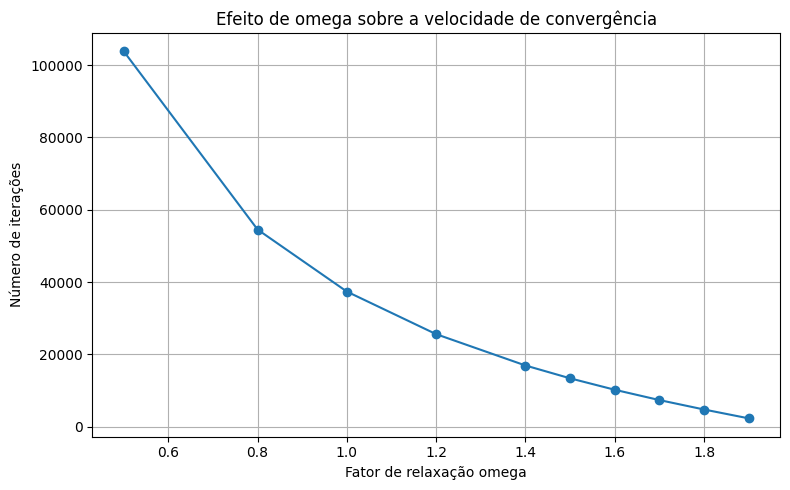

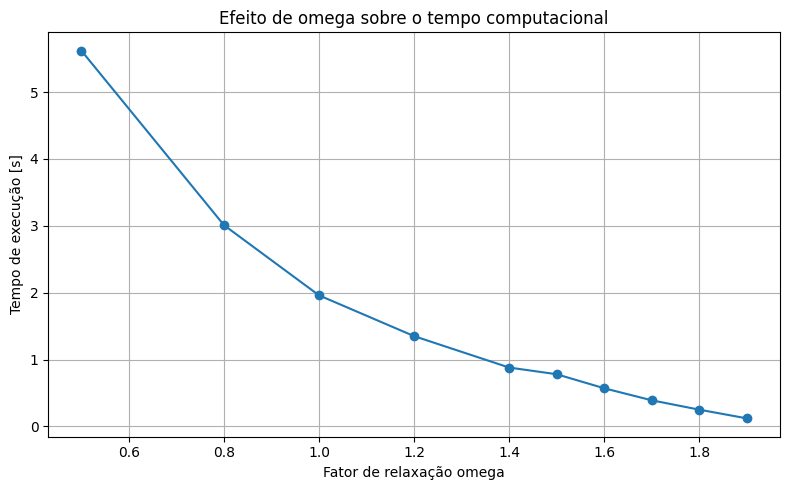

Melhor omega testado = 1.900, com 2265 iterações.


In [6]:
# Valores escolhidos para cobrir sub-relaxação, Gauss-Seidel e sobre-relaxação.
omegas = [
    0.5,
    0.8,
    1.0,
    1.2,
    1.4,
    1.5,
    1.6,
    1.7,
    1.8,
    1.9,
]

# Garante que o omega principal apareça no estudo mesmo se tiver sido alterado pelo usuário.
if all(abs(omega - valor) > 1e-12 for valor in omegas):
    omegas.append(omega)

omegas.sort()
dados_relaxacao = []


for valor in omegas:
    inicio = os.times()[4]

    T_temp, iter_temp, erro_temp, ok_temp, historico_temp = liebmann(
        linhas,
        b,
        chute,
        tol,
        omega=valor,
    )

    tempo_temp = os.times()[4] - inicio
    residuo_temp = residuo_maximo(linhas, b, T_temp)

    dados_relaxacao.append(
        (
            valor,
            iter_temp,
            erro_temp,
            residuo_temp,
            tempo_temp,
            ok_temp,
        )
    )

    print(
        "omega = {:4.2f} | iterações = {:6d} | erro = {:.3e} | resíduo = {:.3e} | tempo = {:.4f} s | convergiu = {}".format(
            valor,
            iter_temp,
            erro_temp,
            residuo_temp,
            tempo_temp,
            ok_temp,
        )
    )


# Seleciona o caso convergente com menor número de iterações.
casos_convergentes = [
    dado
    for dado in dados_relaxacao
    if dado[5]
]

if casos_convergentes:
    melhor_relaxacao = min(
        casos_convergentes,
        key=lambda dado: dado[1],
    )
else:
    melhor_relaxacao = None


# Exportação da tabela completa do estudo.
caminho_relaxacao = os.path.join(pasta, "estudo_relaxacao.dat")

with open(caminho_relaxacao, "w") as arquivo:
    arquivo.write(
        "# omega iteracoes erro_final residuo tempo[s] convergiu\n"
    )

    for dado in dados_relaxacao:
        arquivo.write(
            "{:.8f} {} {:.12e} {:.12e} {:.12e} {}\n".format(
                dado[0],
                dado[1],
                dado[2],
                dado[3],
                dado[4],
                int(dado[5]),
            )
        )


# Número de iterações em função de omega.
plt.figure()
plt.plot(
    [dado[0] for dado in dados_relaxacao],
    [dado[1] for dado in dados_relaxacao],
    "o-",
)
plt.xlabel("Fator de relaxação omega")
plt.ylabel("Número de iterações")
plt.title("Efeito de omega sobre a velocidade de convergência")
plt.tight_layout()
plt.show()


# Tempo medido em função de omega. A tendência deve acompanhar o número de iterações,
# embora pequenas variações de sistema possam introduzir ruído na medição.
plt.figure()
plt.plot(
    [dado[0] for dado in dados_relaxacao],
    [dado[4] for dado in dados_relaxacao],
    "o-",
)
plt.xlabel("Fator de relaxação omega")
plt.ylabel("Tempo de execução [s]")
plt.title("Efeito de omega sobre o tempo computacional")
plt.tight_layout()
plt.show()


if melhor_relaxacao is not None:
    print(
        "Melhor omega testado = {:.3f}, com {} iterações.".format(
            melhor_relaxacao[0],
            melhor_relaxacao[1],
        )
    )

## Análise do efeito de $\omega$

O número de iterações depende fortemente do fator de relaxação. A sub-relaxação torna as atualizações conservadoras e, neste problema, aumenta muito o custo. A sobre-relaxação acelera a propagação das correções pela malha.

O tempo computacional tende a seguir o número de iterações, mas não de maneira perfeitamente proporcional. Como alguns tempos são curtos, pequenas variações do sistema operacional e do ambiente do notebook podem aparecer. Para comparar valores de $\omega$, o número de iterações é uma medida mais estável.

### Resultado com os parâmetros padrão

O caso $\omega=0{,}5$ exigiu **103.880 iterações**, enquanto Gauss-Seidel puro, com $\omega=1$, exigiu **37.345**. O número continuou caindo em toda a faixa testada e chegou a **2.265 iterações** para $\omega=1{,}9$.

Portanto, $\omega=1{,}9$ foi o **melhor valor testado**, mas não se pode afirmar que ele seja o ótimo matemático. Como a curva ainda estava decrescendo no limite superior da varredura, o mínimo não foi completamente cercado. Testes adicionais entre 1,9 e 2 poderiam localizar melhor o ótimo, porém valores muito próximos de 2 aumentam o risco de oscilações e divergência.

O fator mais eficiente depende da geometria, das propriedades e da malha. Ele é uma característica do sistema discretizado, não uma propriedade física universal da aleta.

# 7. Estudo de refinamento de malha

São consideradas três resoluções:

1. uma malha mais grosseira;
2. a malha principal;
3. uma malha refinada, com aproximadamente metade do espaçamento em cada direção.

O refinamento reduz o erro de truncamento das diferenças finitas, mas aumenta o número de incógnitas. Como o problema é bidimensional, dobrar aproximadamente o número de intervalos em $x$ e em $y$ multiplica o total de nós por cerca de quatro.

Neste estudo é usado apenas o método de Liebmann relaxado. Para evitar que o custo do refinamento seja dominado por uma escolha lenta de parâmetro iterativo, utiliza-se o melhor valor de $\omega$ encontrado no estudo anterior. Aplicar eliminação de Gauss densa à malha refinada aumentaria muito o custo e não acrescentaria informação relevante à análise de refinamento.

O erro comparado à solução 1D não é um erro puro de discretização. Ele mistura dois efeitos:

- o erro numérico da malha bidimensional;
- a diferença física entre o modelo 2D e a aproximação analítica 1D.

Por isso, esse erro pode diminuir com o refinamento e depois tender a um valor não nulo. Esse limite representa a diferença entre os modelos, e não uma falha de convergência da solução numérica.

Omega usado no refinamento = 1.900
 11 x   5 | nós =   55 | iterações =    531 | resíduo = 2.621e-11 | erro médio 2D/1D =   0.01010% | tempo = 0.0000 s
 21 x   9 | nós =  189 | iterações =   2265 | resíduo = 2.709e-11 | erro médio 2D/1D =   0.00889% | tempo = 0.1200 s


 41 x  17 | nós =  697 | iterações =   8591 | resíduo = 2.729e-11 | erro médio 2D/1D =   0.00865% | tempo = 1.7000 s


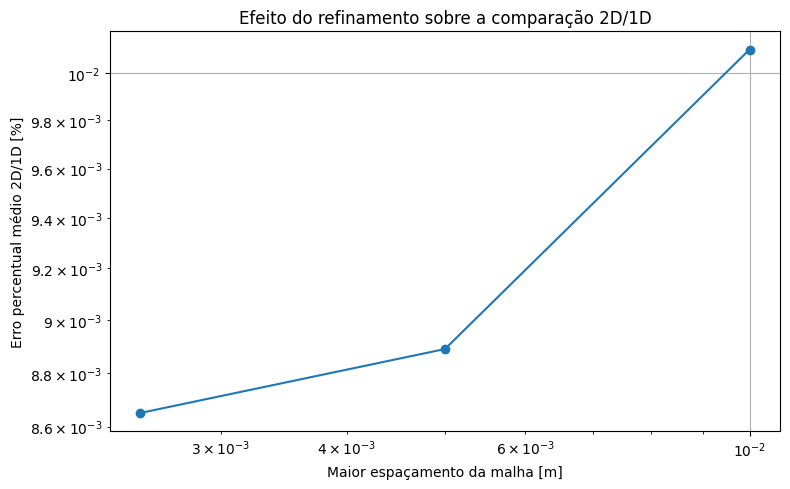

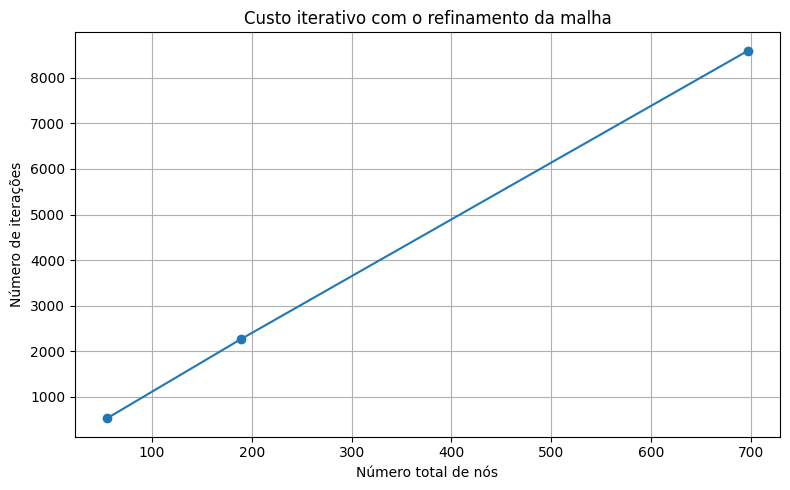

In [7]:
# O estudo usa o melhor fator de relaxação encontrado na varredura anterior.
# Caso nenhum valor tenha convergido, mantém-se o omega principal como alternativa.
if melhor_relaxacao is not None:
    omega_malha = melhor_relaxacao[0]
else:
    omega_malha = omega

print("Omega usado no refinamento = {:.3f}".format(omega_malha))


# Malha grosseira, malha principal e malha com aproximadamente metade do espaçamento.
niveis = [
    (
        max(3, (nx + 1) // 2),
        max(3, (ny + 1) // 2),
    ),
    (nx, ny),
    (
        2 * nx - 1,
        2 * ny - 1,
    ),
]


# Remove uma possível repetição em casos de malhas principais muito pequenas.
niveis_unicos = []

for nivel in niveis:
    if nivel not in niveis_unicos:
        niveis_unicos.append(nivel)


dados_malha = []


for nx_m, ny_m in niveis_unicos:
    # Monta um novo sistema para cada resolução.
    b_m, linhas_m, x_m, y_m, dx_m, dy_m = montar_sistema(
        L,
        H,
        k,
        h,
        Tb,
        Tinf,
        nx_m,
        ny_m,
    )

    # Constrói o chute inicial correspondente à nova malha.
    chute_m = [Tinf] * (nx_m * ny_m)

    for j in range(ny_m):
        chute_m[j * nx_m] = Tb

    # Resolve o sistema com o melhor omega identificado no estudo de relaxação.
    inicio = os.times()[4]

    T_m, it_m, erro_m, ok_m, hist_m = liebmann(
        linhas_m,
        b_m,
        chute_m,
        tol,
        omega=omega_malha,
    )

    tempo_m = os.times()[4] - inicio
    residuo_m = residuo_maximo(linhas_m, b_m, T_m)

    # Extrai a linha central para a resolução atual.
    if ny_m % 2 == 1:
        j_centro_m = ny_m // 2
        centro_m = [
            T_m[j_centro_m * nx_m + i]
            for i in range(nx_m)
        ]

    else:
        j_inferior_m = ny_m // 2 - 1
        j_superior_m = ny_m // 2

        centro_m = [
            0.5 * (
                T_m[j_inferior_m * nx_m + i]
                + T_m[j_superior_m * nx_m + i]
            )
            for i in range(nx_m)
        ]

    # Compara a linha central da nova malha com a mesma solução analítica 1D.
    erros_m = []

    for i in range(nx_m):
        numerador_m = (
            math.cosh(m * (L - x_m[i]))
            + fator_ponta * math.sinh(m * (L - x_m[i]))
        )

        theta_m = numerador_m / denominador
        valor_analitico_m = Tinf + (Tb - Tinf) * theta_m

        escala_m = max(
            abs(valor_analitico_m),
            abs(Tb - Tinf) * 1e-12,
            1e-12,
        )

        erro_local_m = (
            100.0
            * abs(centro_m[i] - valor_analitico_m)
            / escala_m
        )

        erros_m.append(erro_local_m)

    erro_pct_m = sum(erros_m) / len(erros_m)

    dados_malha.append(
        (
            nx_m,
            ny_m,
            nx_m * ny_m,
            dx_m,
            dy_m,
            it_m,
            erro_m,
            residuo_m,
            tempo_m,
            erro_pct_m,
            ok_m,
        )
    )

    print(
        "{:3d} x {:3d} | nós = {:4d} | iterações = {:6d} | resíduo = {:.3e} | erro médio 2D/1D = {:9.5f}% | tempo = {:.4f} s".format(
            nx_m,
            ny_m,
            nx_m * ny_m,
            it_m,
            residuo_m,
            erro_pct_m,
            tempo_m,
        )
    )


# Exporta todas as métricas do estudo de refinamento.
caminho_malha = os.path.join(pasta, "estudo_malha.dat")

with open(caminho_malha, "w") as arquivo:
    arquivo.write(
        "# nx ny nos dx[m] dy[m] iteracoes erro_iterativo residuo tempo[s] erro_percentual_medio convergiu\n"
    )

    for dado in dados_malha:
        arquivo.write(
            "{} {} {} {:.12e} {:.12e} {} {:.12e} {:.12e} {:.12e} {:.12e} {}\n".format(
                dado[0],
                dado[1],
                dado[2],
                dado[3],
                dado[4],
                dado[5],
                dado[6],
                dado[7],
                dado[8],
                dado[9],
                int(dado[10]),
            )
        )


# Erro médio em função do espaçamento representativo da malha.
plt.figure()
plt.plot(
    [max(dado[3], dado[4]) for dado in dados_malha],
    [dado[9] for dado in dados_malha],
    "o-",
)
plt.xscale("log")

if all(dado[9] > 0.0 for dado in dados_malha):
    plt.yscale("log")

plt.xlabel("Maior espaçamento da malha [m]")
plt.ylabel("Erro percentual médio 2D/1D [%]")
plt.title("Efeito do refinamento sobre a comparação 2D/1D")
plt.tight_layout()
plt.show()


# Custo iterativo em função do número total de nós.
plt.figure()
plt.plot(
    [dado[2] for dado in dados_malha],
    [dado[5] for dado in dados_malha],
    "o-",
)
plt.xlabel("Número total de nós")
plt.ylabel("Número de iterações")
plt.title("Custo iterativo com o refinamento da malha")
plt.tight_layout()
plt.show()

## Análise do refinamento

Uma solução numericamente consistente deve se tornar menos sensível à malha conforme os espaçamentos são reduzidos. Ao mesmo tempo, o aumento do número de nós eleva o custo de cada iteração e pode aumentar também o número de iterações necessário para atingir a mesma tolerância.

A comparação com a solução 1D deve ser interpretada com cuidado. Se o erro médio diminuir da malha grosseira para a principal, isso indica que parte da discrepância vinha da discretização. Se a redução se tornar pequena na malha refinada, a diferença remanescente provavelmente está associada às hipóteses distintas dos modelos 2D e 1D.

Para uma análise formal de ordem de convergência seria preferível comparar as malhas com uma solução bidimensional de referência muito refinada ou usar extrapolação de Richardson. A solução analítica 1D não cumpre exatamente esse papel porque resolve um modelo físico simplificado.

### Resultado com os parâmetros padrão

O erro médio em relação ao modelo 1D caiu de **0,01010%** na malha $11\times5$ para **0,00889%** na malha $21\times9$ e **0,00865%** na malha $41\times17$. A redução existe, mas se torna progressivamente menor.

Esse comportamento sugere que a malha principal já representa bem o campo e que parte importante do erro remanescente não vem da discretização, mas da diferença entre os modelos 2D e 1D. Ao mesmo tempo, o custo cresceu de **531** para **2.265** e depois **8.591 iterações**, mostrando o preço computacional do refinamento.

A malha refinada tem aproximadamente quatro vezes mais nós que a principal, mas exige mais de três vezes o número de iterações. Como cada iteração também percorre mais nós, o custo total cresce de forma ainda mais acentuada.

# 8. Campo bidimensional e contornos isotérmicos

O campo calculado pelo método relaxado é reorganizado em uma matriz com `ny` linhas e `nx` colunas. O mapa de temperatura mostra diretamente a distribuição espacial, enquanto os contornos isotérmicos facilitam a observação das regiões com mesma temperatura.

Espera-se um campo aproximadamente simétrico em relação à linha central horizontal, pois as superfícies superior e inferior possuem as mesmas condições convectivas. A temperatura deve cair da base para a ponta e também da linha central para as superfícies expostas.

Uma perda de simetria significativa, sem alteração das condições de contorno, indicaria erro na numeração dos nós ou na montagem das equações das fronteiras.

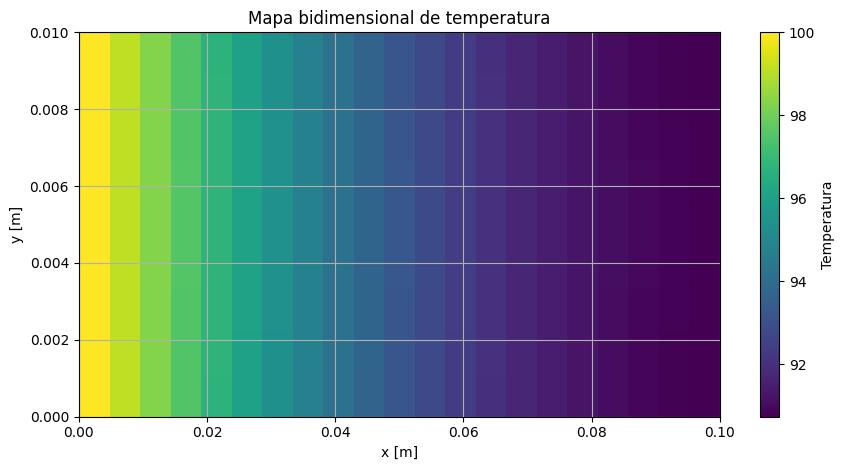

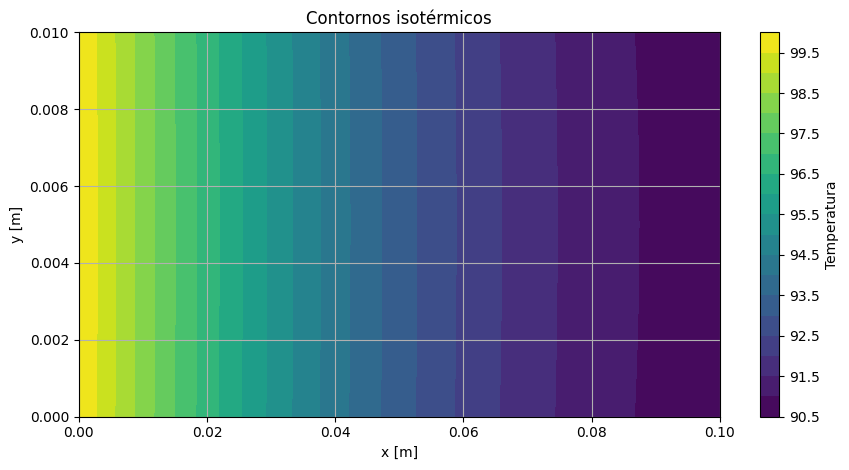

Maior diferença de simetria em relação à linha central = 3.984954e-08 K
Temperatura máxima no campo = 100.000000
Temperatura mínima no campo = 90.740316


In [8]:
# Converte o vetor global de temperaturas em uma matriz organizada por fileiras da malha.
campo = [
    [
        T_relax[j * nx + i]
        for i in range(nx)
    ]
    for j in range(ny)
]


# Mapa bidimensional de temperatura.
plt.figure(figsize=(9, 4.8))
plt.imshow(
    campo,
    origin="lower",
    extent=[0.0, L, 0.0, H],
    aspect="auto",
)
barra = plt.colorbar()
barra.set_label("Temperatura")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Mapa bidimensional de temperatura")
plt.tight_layout()
plt.show()


# Curvas de nível preenchidas.
plt.figure(figsize=(9, 4.8))
contorno = plt.contourf(
    x,
    y,
    campo,
    20,
)
barra = plt.colorbar(contorno)
barra.set_label("Temperatura")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Contornos isotérmicos")
plt.tight_layout()
plt.show()


# Verificação simples da simetria entre as metades superior e inferior.
erro_simetria = 0.0

for j in range(ny):
    j_espelhado = ny - 1 - j

    for i in range(nx):
        diferenca = abs(
            campo[j][i]
            - campo[j_espelhado][i]
        )

        if diferenca > erro_simetria:
            erro_simetria = diferenca


print("Maior diferença de simetria em relação à linha central = {:.6e} K".format(erro_simetria))
print("Temperatura máxima no campo = {:.6f}".format(max(T_relax)))
print("Temperatura mínima no campo = {:.6f}".format(min(T_relax)))

# 9. Conclusões

O método das diferenças finitas transforma a equação de Laplace e suas condições de contorno em um sistema linear esparso. A esparsidade surge porque cada temperatura nodal depende apenas do próprio nó e de seus vizinhos imediatos.

A eliminação de Gauss é útil como referência para a malha principal, mas sua representação densa não aproveita essa estrutura. Os métodos de Liebmann são mais naturais para o problema, pois operam diretamente sobre os coeficientes não nulos. A relaxação modifica apenas a trajetória iterativa; quando há convergência, o campo final deve permanecer compatível com a solução do mesmo sistema.

A comparação com a solução analítica 1D confirma a tendência física de resfriamento ao longo da aleta, mas também evidencia as diferenças entre os modelos. O campo bidimensional captura gradientes transversais, resfriamento mais intenso nas superfícies, efeitos de canto e a condição local da extremidade livre.

O estudo de $\omega$ mostra que a sobre-relaxação pode reduzir o custo iterativo, desde que o fator não seja excessivo. O estudo de malha mostra simultaneamente a redução do erro de discretização e o crescimento do custo computacional.

Por fim, a simetria do campo em relação à linha central, a concordância entre os três métodos e os resíduos pequenos constituem verificações independentes da implementação. Os arquivos `.dat` preservam os campos e as métricas necessárias para reprodução e análise posterior.

## Síntese dos resultados padrão

O campo permaneceu simétrico em relação à linha central, com diferença máxima de apenas $3{,}98\times10^{-8}$ K entre pontos espelhados. A temperatura variou de **100** na base até aproximadamente **90,7403** na região mais fria da extremidade livre.

Em conjunto, quatro verificações apontam para uma implementação consistente: concordância entre os três métodos, resíduos pequenos, simetria do campo e proximidade com a solução analítica 1D. O refinamento adicional altera pouco a comparação 2D/1D, indicando que a malha principal oferece um bom compromisso entre custo e precisão para os parâmetros adotados.

In [9]:
# O resumo reúne os resultados mais importantes em um único arquivo de texto .dat.
caminho_resumo = os.path.join(pasta, "resumo_resultados.dat")

with open(caminho_resumo, "w") as arquivo:
    arquivo.write("PPC6 - RESUMO DOS RESULTADOS\n")
    arquivo.write("========================================\n")
    arquivo.write("Comprimento L [m]: {:.12e}\n".format(L))
    arquivo.write("Espessura H [m]: {:.12e}\n".format(H))
    arquivo.write("Condutividade k [W/(m.K)]: {:.12e}\n".format(k))
    arquivo.write("Coeficiente convectivo h [W/(m2.K)]: {:.12e}\n".format(h))
    arquivo.write("Temperatura da base: {:.12e}\n".format(Tb))
    arquivo.write("Temperatura ambiente: {:.12e}\n".format(Tinf))
    arquivo.write("Malha principal: {} x {} = {} nós\n".format(nx, ny, n))
    arquivo.write("dx [m]: {:.12e}\n".format(dx))
    arquivo.write("dy [m]: {:.12e}\n".format(dy))
    arquivo.write("Coeficientes não nulos: {}\n".format(nnz))
    arquivo.write("Densidade da matriz [%]: {:.12e}\n".format(densidade))

    arquivo.write("\nCOMPARAÇÃO DOS MÉTODOS\n")
    arquivo.write("Gauss - resíduo: {:.12e}\n".format(res_gauss))
    arquivo.write("Gauss - tempo [s]: {:.12e}\n".format(tempo_gauss))
    arquivo.write("Liebmann - iterações: {}\n".format(it_lieb))
    arquivo.write("Liebmann - erro final: {:.12e}\n".format(erro_lieb))
    arquivo.write("Liebmann - resíduo: {:.12e}\n".format(res_lieb))
    arquivo.write("Liebmann - tempo [s]: {:.12e}\n".format(tempo_lieb))
    arquivo.write("Relaxado - omega: {:.12e}\n".format(omega))
    arquivo.write("Relaxado - iterações: {}\n".format(it_relax))
    arquivo.write("Relaxado - erro final: {:.12e}\n".format(erro_relax))
    arquivo.write("Relaxado - resíduo: {:.12e}\n".format(res_relax))
    arquivo.write("Relaxado - tempo [s]: {:.12e}\n".format(tempo_relax))
    arquivo.write("Diferença máxima Liebmann/Gauss [K]: {:.12e}\n".format(dif_lieb))
    arquivo.write("Diferença máxima relaxado/Gauss [K]: {:.12e}\n".format(dif_relax))

    arquivo.write("\nCOMPARAÇÃO 2D/1D\n")
    arquivo.write("Erro percentual médio: {:.12e}\n".format(erro_percentual))
    arquivo.write("Erro percentual máximo: {:.12e}\n".format(erro_percentual_maximo))

    arquivo.write("\nVERIFICAÇÕES DO CAMPO\n")
    arquivo.write("Erro máximo de simetria [K]: {:.12e}\n".format(erro_simetria))
    arquivo.write("Temperatura máxima: {:.12e}\n".format(max(T_relax)))
    arquivo.write("Temperatura mínima: {:.12e}\n".format(min(T_relax)))

    if melhor_relaxacao is not None:
        arquivo.write("\nESTUDO DE RELAXAÇÃO\n")
        arquivo.write("Melhor omega testado: {:.12e}\n".format(melhor_relaxacao[0]))
        arquivo.write("Iterações no melhor caso: {}\n".format(melhor_relaxacao[1]))

    arquivo.write("\nINTERPRETAÇÃO\n")
    arquivo.write("A matriz é esparsa porque cada nó se acopla apenas aos vizinhos imediatos.\n")
    arquivo.write("O modelo 2D captura gradientes transversais, efeitos de canto e da extremidade livre.\n")
    arquivo.write("A convecção reduz a temperatura em direção às superfícies e à ponta da aleta.\n")


print("\nExecução concluída.")
print("Todos os arquivos .dat foram salvos em:", pasta)
print("Arquivo de resumo:", caminho_resumo)


Execução concluída.
Todos os arquivos .dat foram salvos em: /tmp/ppc6_exec/resultados_PPC6
Arquivo de resumo: /tmp/ppc6_exec/resultados_PPC6/resumo_resultados.dat
